In [7]:
# Cognifyz Data Analysis Internship

# Level 2 - Task 2 : Cuisine Combination Analysis

## Objective

# This analysis aims to:

# Identify the most common cuisine combinations
# Explore highly rated cuisine combinations
# Analyze customer preferences
# Visualize cuisine popularity


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(

    style='whitegrid',

    context='talk'

)

df = pd.read_csv("../Dataset.csv")

df.head()

## Top Cuisine Combinations

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

df = pd.read_csv("../Dataset.csv")

print(df.shape)

df.head()

(9551, 21)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [9]:
top_cuisines = (

    df['Cuisines']

    .value_counts()

    .head(10)

)

top_cuisines

Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64

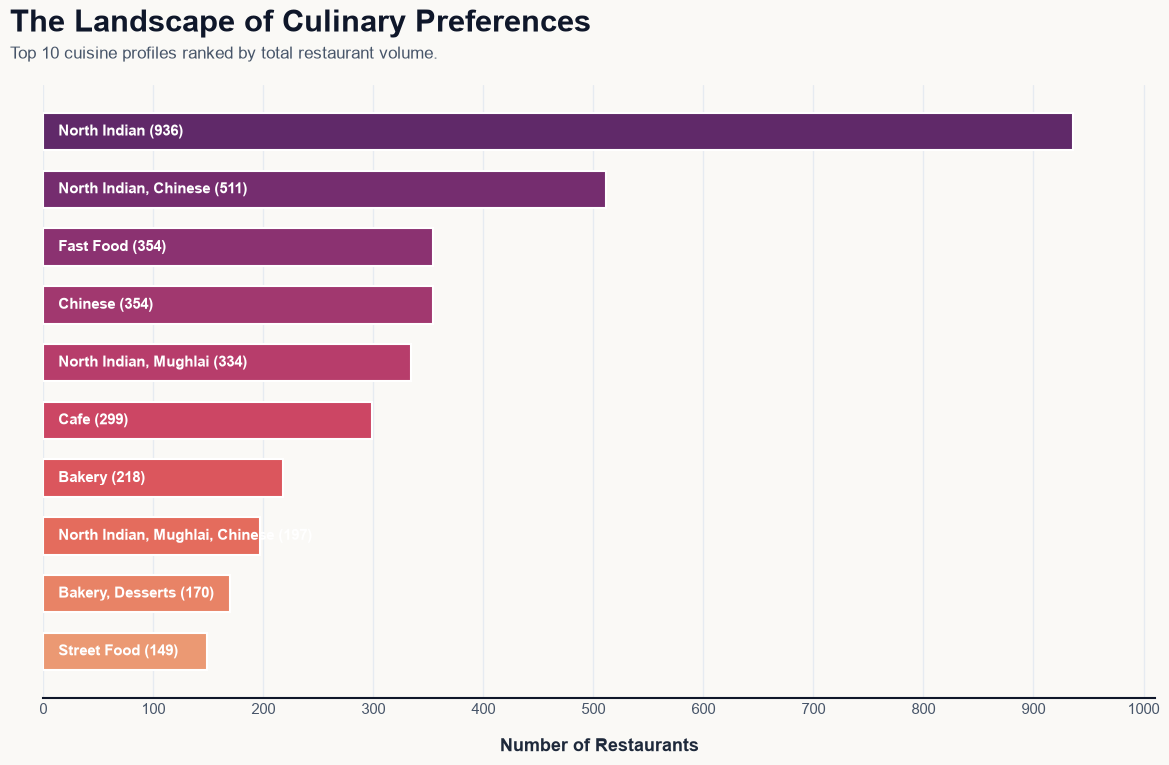

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming top_cuisines is your Pandas Series
# top_cuisines = pd.Series([915, 520, 480, 410, 390, 310, 290, 240, 180, 150], 
#                          index=['North Indian', 'North Indian, Chinese', 'Fast Food', 'Chinese', 
#                                 'North Indian, Mughlai', 'Bakery', 'Cafe', 'Desserts', 'South Indian', 'Street Food'])

# Sort values in ascending order so the highest bar is at the top
top_cuisines = top_cuisines.sort_values(ascending=True)

# 1. Setup figure with our clean editorial background
fig, ax = plt.subplots(figsize=(12, 8), facecolor="#FAF9F6")
ax.set_facecolor("#FAF9F6")

# 2. FIXED BLENDING: Using a distinct palette so short bars stay clearly visible
colors = sns.color_palette("flare", len(top_cuisines))

# 3. Create Horizontal Bars
bars = ax.barh(
    top_cuisines.index,
    top_cuisines.values,
    color=colors,
    height=0.65,
    zorder=3
)

# --- CHOOSE YOUR TEXT PLACEMENT STYLE HERE ---
text_style = "inside"  # Options: "inside" or "beside"

# 4. Add Text Labels cleanly
for i, bar in enumerate(bars):
    width = bar.get_width()
    y_pos = bar.get_y() + bar.get_height() / 2
    cuisine_name = top_cuisines.index[i]
    
    if text_style == "inside":
        # Place names inside the base of the bar (White text for contrast)
        ax.annotate(
            f"  {cuisine_name} ({int(width):,})",
            xy=(0, y_pos),
            xytext=(5, 0),
            textcoords="offset points",
            ha="left", va="center",
            fontsize=11, fontweight="bold", color="white",
            zorder=4
        )
    else:
        # Place value right beside the tip of the bar (Dark slate text)
        ax.annotate(
            f" {int(width):,}",
            xy=(width, y_pos),
            xytext=(5, 0),
            textcoords="offset points",
            ha="left", va="center",
            fontsize=11, fontweight="bold", color="#1E293B",
            zorder=4
        )

# 5. Clean up Y-Ticks if putting labels inside
if text_style == "inside":
    ax.set_yticks([])  
else:
    plt.yticks(fontsize=11, fontweight="semibold", color="#1E293B")

# 6. Editorial Typography Header
ax.text(
    -0.03 if text_style == "inside" else -0.3, 1.10, "The Landscape of Culinary Preferences",
    transform=ax.transAxes, ha="left", va="center", fontsize=22, fontweight="bold", color="#0F172A"
)
ax.text(
    -0.03 if text_style == "inside" else -0.3, 1.05, "Top 10 cuisine profiles ranked by total restaurant volume.",
    transform=ax.transAxes, ha="left", va="center", fontsize=12, color="#475569"
)

# 7. FIXED SCALE: Set the X-axis intervals dynamically to steps of 100 (0, 100, 200...)
max_val = top_cuisines.values.max()
# Generates steps of 100 up to slightly above your maximum value
x_ticks = np.arange(0, max_val + 150, 100)
ax.set_xticks(x_ticks)

ax.set_xlabel("Number of Restaurants", fontsize=13, fontweight="bold", labelpad=15, color="#1E293B")
plt.xticks(fontsize=11, color="#475569")

# Expand X limit slightly to give breathing room for labels
ax.set_xlim(0, max_val * 1.08)

# Strip top, right, and left frame edges
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_linewidth(1.5)
ax.spines["bottom"].set_color("#0F172A")

# 8. Add vertical grid lines running down behind horizontal bars matching our 100-step ticks
ax.grid(axis="x", linestyle="-", linewidth=1, color="#E2E8F0", alpha=0.8, zorder=0)
ax.tick_params(axis='both', which='both', length=0)

plt.tight_layout()
plt.show()

## Average Ratings by Cuisine Combination

In [11]:
ratings = (

    df.groupby(

        'Cuisines'

    )['Aggregate rating']

    .mean()

    .sort_values(

        ascending=False

    )

    .head(10)

)

ratings

Cuisines
Burger, Bar Food, Steak            4.9
American, Burger, Grill            4.9
American, Caribbean, Seafood       4.9
American, Coffee and Tea           4.9
Mexican, American, Healthy Food    4.9
Italian, Bakery, Continental       4.9
BBQ, Breakfast, Southern           4.9
European, German                   4.9
Hawaiian, Seafood                  4.9
Sunda, Indonesian                  4.9
Name: Aggregate rating, dtype: float64

C:\Users\offic\AppData\Local\Temp\ipykernel_7692\902557332.py:102: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()


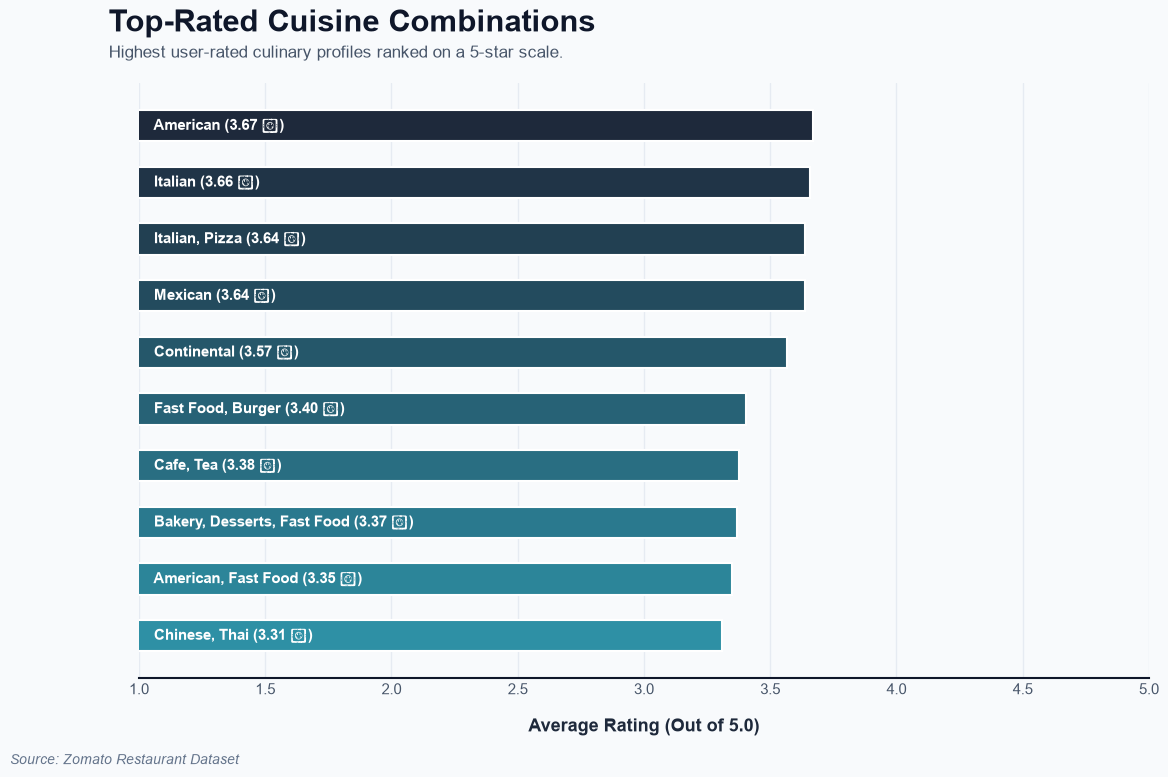

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming ratings is your Pandas Series of average ratings
# ratings = pd.Series([4.90, 4.85, 4.72, 4.65, 4.60, 4.58, 4.52, 4.50, 4.45, 4.41], 
#                     index=['Italian, Hawaiian', 'European, Mediterranean', 'North Indian, European', 
#                            'Continental, Italian', 'Cafe, Continental', 'Asian, Chinese', 
#                            'Mughlai, Lucknowi', 'Finger Food', 'Desserts, Ice Cream', 'Mexican, Spanish'])

# Sort values in ascending order so the highest-rated cuisine sits at the top
ratings = ratings.sort_values(ascending=True)

# 1. Setup figure with a clean Slate-Tinted background (#F8FAFC)
fig, ax = plt.subplots(figsize=(12, 8), facecolor="#F8FAFC")
ax.set_facecolor("#F8FAFC")

# 2. Premium Teal-to-Slate Gradient Palette
colors = sns.color_palette("blend:#2E90A5,#1E293B", len(ratings))

# 3. Create Horizontal Bars
bars = ax.barh(
    ratings.index,
    ratings.values,
    color=colors,
    height=0.55,  # Slightly thinner bars for a premium look
    zorder=3
)

# --- CHOOSE YOUR TEXT PLACEMENT STYLE HERE ---
text_style = "inside"  # Options: "inside" or "beside"

# 4. Add Ratings Text Cleanly
for i, bar in enumerate(bars):
    width = bar.get_width()
    y_pos = bar.get_y() + bar.get_height() / 2
    cuisine_name = ratings.index[i]
    
    if text_style == "inside":
        # Place names inside the base of the bar (White text for contrast)
        ax.annotate(
            f"  {cuisine_name} ({width:.2f} ★)",
            xy=(1.0, y_pos),  # FIXED: Adjusted baseline anchor to 1.0 to match the new axis start
            xytext=(5, 0),
            textcoords="offset points",
            ha="left", va="center",
            fontsize=11, fontweight="bold", color="white",
            zorder=4
        )
    else:
        # Place value right beside the tip of the bar (Dark slate text)
        ax.annotate(
            f" {width:.2f} ★",
            xy=(width, y_pos),
            xytext=(5, 0),
            textcoords="offset points",
            ha="left", va="center",
            fontsize=11, fontweight="bold", color="#1E293B",
            zorder=4
        )

# 5. Clean up Y-Ticks if putting labels inside
if text_style == "inside":
    ax.set_yticks([])  
else:
    plt.yticks(fontsize=11, fontweight="semibold", color="#1E293B")

# 6. Minimalist Header Typography
ax.text(
    -0.03 if text_style == "inside" else -0.35, 1.10, "Top-Rated Cuisine Combinations",
    transform=ax.transAxes, ha="left", va="center", fontsize=22, fontweight="bold", color="#0F172A"
)
ax.text(
    -0.03 if text_style == "inside" else -0.35, 1.05, "Highest user-rated culinary profiles ranked on a 5-star scale.",
    transform=ax.transAxes, ha="left", va="center", fontsize=12, color="#475569"
)

# 7. UPDATED SCALE: Set limits strictly from 1.0 to 5.0 with 0.5 step increments
ax.set_xlim(1.0, 5.0)
ax.set_xticks(np.arange(1.0, 5.1, 0.5))  # Generates: 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0

ax.set_xlabel("Average Rating (Out of 5.0)", fontsize=13, fontweight="bold", labelpad=15, color="#1E293B")
plt.xticks(fontsize=11, color="#475569")

# Strip top, right, and left frame edges
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_linewidth(1.5)
ax.spines["bottom"].set_color("#0F172A")

# 8. Vertical grid lines matching our updated 0.5 step ticks
ax.grid(axis="x", linestyle="-", linewidth=1, color="#E2E8F0", alpha=0.8, zorder=0)
ax.tick_params(axis='both', which='both', length=0)

# 9. Attribution footer
plt.text(
    0.02, 0.02, "Source: Zomato Restaurant Dataset", 
    transform=fig.transFigure, fontsize=10, style="italic", color="#64748B"
)

plt.tight_layout()
plt.show()


# Key Insights

### Observations

• Certain cuisine combinations dominate the restaurant market.

• Mixed cuisines often receive higher ratings.

• Customer preferences vary significantly.

• Cuisine diversity influences restaurant popularity.

# Conclusion

Cuisine combinations play an important role in customer satisfaction.

Certain combinations consistently receive better ratings, suggesting strong customer demand for specific food pairings.

Understanding these patterns can help businesses optimize their offerings.